In [49]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from bayesgpt.simulators.benchmarks import SuperDDM, StandardDDM, CollapsingBoundDDM

### Model

In [51]:
model = SuperDDM(dt=0.0001, max_steps=100000)

### Single drift DDM

In [53]:
params_single = {
    "v": 0.5,         # Single drift rate
    "a": 1.0,
    "z": 0.5,
    "tau": 0.1,
    "s_v": 0.1,
    "sigma": 1.0,
    "angle": 0.0,
    "s_z": 0.01,
    "s_tau": 0.01
}
result_single = model.simulate(params_single, num_samples=1000)
# print("Single Drift RTs:", result_single["rts"])
# print("Single Drift Choices:", result_single["choices"])

### Mixture DDM (within-trial drift variability)

In [64]:
params_mixture = {
    "v_components": np.array([0.5, -0.5]),
    "p_components": np.array([0.5, 0.5]),  # Balanced probabilities for more variability
    "a": 1.0,
    "z": 0.5,
    "tau": 0.1,
    "s_v": 0.1,
    "sigma": 1.0,
    "angle": 0.0,
    "s_z": 0.01,
    "s_tau": 0.01
}
result_mixture = model.simulate(params_mixture, num_samples=1000)
# print("Mixture Drift RTs:", result_mixture["rts"])
# print("Mixture Drift Choices:", result_mixture["choices"])

### Schedule DDM (across-trial drift variability)

In [52]:
params_schedule = {
    "v_schedule": np.array([0.5, 1.0, -0.5]),  # Drift changes over time
    "t_schedule": np.array([0.0, 0.2, 0.4]),   # Times when drifts change
    "a": 1.0,         # Boundary separation
    "z": 0.5,         # Starting point (relative to a)
    "tau": 0.1,       # Non-decision time
    "s_v": 0.1,       # Drift variability
    "sigma": 1.0,     # Diffusion noise
    "angle": 0.0,     # No collapsing boundary
    "s_z": 0.01,      # Starting point variability
    "s_tau": 0.01     # Non-decision time variability
}
result_schedule = model.simulate(params_schedule, num_samples=1000)
# print("Scheduled Drift RTs:", result_schedule["rts"])
# print("Scheduled Drift Choices:", result_schedule["choices"])

### Context Modulation

In [65]:
def context_modulation(params: dict, context: np.ndarray) -> dict:
    """
    Example modulation:
      - v scaled by (1 + 0.8 * ctx)      where ctx in [-1, 1]
      - a scaled by (1 - 0.3 * ctx)      (harder task => higher ctx => slightly lower bound)
      - z nudged toward center: z <- 0.5 + 0.5*(z-0.5)*(1 - 0.5*ctx)
      - tau shortened slightly with ctx: tau <- tau * (1 - 0.1*ctx)
      - angle increased with ctx: angle <- angle * (1 + 0.5*ctx)
    Ensures constraints: a>0, sigma>0, 0<z<1
    """
    p = {k: (v.copy() if isinstance(v, np.ndarray) else v) for k, v in params.items()}

    # scalar → vector broadcasting is handled inside SuperDDM, but we modulate elementwise if arrays exist
    def _same_shape(x):
        return x if isinstance(x, np.ndarray) and x.shape == context.shape else np.full_like(context, x, dtype=np.float32)

    a = _same_shape(p["a"]) * (1.0 - 0.3 * context)
    v_scalar = p.get("v", None)
    if v_scalar is not None:
        v = _same_shape(v_scalar) * (1.0 + 0.8 * context)
        p["v"] = v.astype(np.float32)

    if "v_components" in p:
        # scale each component by the same context factor per trial
        vc = p["v_components"].astype(np.float32)
        scale = (1.0 + 0.8 * context)[:, None]
        p["v_components"] = vc * scale

    if "v_schedule" in p:
        vs = p["v_schedule"].astype(np.float32)
        scale = (1.0 + 0.8 * context)[:, None]
        p["v_schedule"] = vs * scale

    z = _same_shape(p["z"])
    z = 0.5 + (z - 0.5) * (1.0 - 0.5 * context)  # pull toward center with ctx
    tau = _same_shape(p["tau"]) * (1.0 - 0.1 * context)
    angle = _same_shape(p["angle"]) * (1.0 + 0.5 * context)

    # apply + clip
    p["a"] = np.clip(a, 1e-4, None).astype(np.float32)
    p["z"] = np.clip(z, 1e-3, 1.0 - 1e-3).astype(np.float32)
    p["tau"] = np.clip(tau, 0.0, None).astype(np.float32)
    p["angle"] = np.clip(angle, 0.0, None).astype(np.float32)

    return p

In [66]:
def summarize(tag: str, out: dict):
    rts = out["rts"]
    choices = out["choices"]
    mask = ~np.isnan(rts)
    valid = mask.sum()
    acc = np.nan
    if valid > 0:
        acc = np.nanmean(choices[mask])
    print(f"[{tag}] valid={valid}/{len(rts)}  mean_rt={np.nanmean(rts):.4f}  acc={acc:.3f}")


def make_context(num_samples: int, low: float = -1.0, high: float = 1.0, seed: int = 0):
    rng = np.random.default_rng(seed)
    return rng.uniform(low, high, size=num_samples).astype(np.float32)

In [67]:
def run_single_drift(ddm: SuperDDM, num_samples: int, seed: int = 1):
    np.random.seed(seed)
    params = dict(
        v=1.0,           # single drift
        a=1.2,
        z=0.5,
        tau=0.3,
        s_v=0.2,
        sigma=1.0,
        angle=0.2,
        s_z=0.05,
        s_tau=0.02,
    )
    ctx = make_context(num_samples, seed=seed)
    out = ddm.simulate(params=params, num_samples=num_samples, context=ctx, modulation=context_modulation)
    summarize("single_drift + context", out)
    return out


def run_mixture_drift(ddm: SuperDDM, num_samples: int, seed: int = 2):
    np.random.seed(seed)
    # Two-component mixture with (optionally) unnormalized p; the model normalizes internally.
    params = dict(
        v_components=np.array([0.6, 1.5], dtype=np.float32),  # broadcast to (N, 2)
        p_components=np.array([1.0, 2.0], dtype=np.float32),  # broadcast to (N, 2)
        a=1.1,
        z=0.45,
        tau=0.28,
        s_v=0.25,
        sigma=1.0,
        angle=0.15,
        s_z=0.06,
        s_tau=0.03,
    )
    ctx = make_context(num_samples, seed=seed)
    out = ddm.simulate(params=params, num_samples=num_samples, context=ctx, modulation=context_modulation)
    summarize("mixture_drift + context", out)
    return out


def run_schedule_drift(ddm: SuperDDM, num_samples: int, seed: int = 3):
    np.random.seed(seed)
    # Two-segment schedule: drift switches at t = 0.35s
    v_schedule = np.array([0.4, 1.2], dtype=np.float32)   # broadcast to (N, 2)
    t_schedule = np.array([0.35, 0.70], dtype=np.float32) # times of segment starts (nondecreasing)
    params = dict(
        v_schedule=v_schedule,
        t_schedule=t_schedule,
        a=1.0,
        z=0.5,
        tau=0.25,
        s_v=0.2,
        sigma=1.0,
        angle=0.25,
        s_z=0.05,
        s_tau=0.02,
    )
    ctx = make_context(num_samples, seed=seed)
    out = ddm.simulate(params=params, num_samples=num_samples, context=ctx, modulation=context_modulation)
    summarize("schedule_drift + context", out)
    return out

In [68]:
num_samples = 1000  # per variant
ddm = SuperDDM(dt=0.001, max_steps=10_000)
print("Running SuperDDM with context modulation...\n")
result_mod_single = run_single_drift(ddm, num_samples)
result_mod_mixture = run_mixture_drift(ddm, num_samples)
result_mod_schedule = run_schedule_drift(ddm, num_samples)

Running SuperDDM with context modulation...

[single_drift + context] valid=1000/1000  mean_rt=0.8313  acc=0.962
[mixture_drift + context] valid=1000/1000  mean_rt=0.8010  acc=0.949
[schedule_drift + context] valid=1000/1000  mean_rt=0.7173  acc=0.928


In [69]:
results = {
    "single": result_single,
    "mixture": result_mixture,
    "schedule": result_schedule,
    "single_ctx": result_mod_single,
    "mixture_ctx": result_mod_mixture,
    "schedule_ctx": result_mod_schedule
}

### Visualization

In [70]:
# C h i c   p a l e t t e   f o r   a e s t h e t i c s
palette = {
    "single":       "#1B3A6F",  # deep Delft blue
    "single_ctx":   "#2C6CC9",  # bright Delft blue
    "mixture":      "#A23B1E",  # canal brick red
    "mixture_ctx":  "#E4572E",  # vivid brick/orange
    "schedule":     "#005F73",  # North Sea teal
    "schedule_ctx": "#0A9396",  # sea green
}

sns.set_palette([palette[k] for k in results.keys()])

In [71]:
def _valid_mask(*arrs):
    m = np.ones_like(arrs[0], dtype=bool)
    for a in arrs:
        m &= ~np.isnan(a)
    return m

def invalid_rate(rt):
    return float(np.mean(np.isnan(rt))) if rt.size else np.nan

def fd_bin_width(x):
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    n = x.size
    if n < 2:
        return 0.05
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    if iqr <= 0:
        rng = x.max() - x.min()
        return max(rng / 50.0, 0.01) if rng > 0 else 0.05
    return 2.0 * iqr * n ** (-1/3)

def common_bins(results, xlim=None):
    all_rts = np.concatenate([v["rts"][~np.isnan(v["rts"])] for v in results.values()])
    rt_min, rt_max = (np.nanmin(all_rts), np.nanmax(all_rts)) if xlim is None else xlim
    w = fd_bin_width(all_rts)
    edges = np.arange(rt_min, rt_max + w, w)
    if edges.size < 5:
        edges = np.linspace(rt_min, rt_max, 50)
    return edges

def binned_stats(x, y, nbins=20, rng=None):
    x, y = np.asarray(x), np.asarray(y)
    m = _valid_mask(x, y)
    x, y = x[m], y[m]
    if x.size == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])
    xmin, xmax = (x.min(), x.max()) if rng is None else rng
    edges = np.linspace(xmin, xmax, nbins + 1)
    idx = np.digitize(x, edges) - 1
    centers, med, lo, hi = [], [], [], []
    for b in range(nbins):
        sel = idx == b
        if sel.sum() < 5:
            continue
        yb = y[sel]
        centers.append(0.5 * (edges[b] + edges[b+1]))
        med.append(np.median(yb))
        lo.append(np.percentile(yb, 25))
        hi.append(np.percentile(yb, 75))
    return np.array(centers), np.array(med), np.array(lo), np.array(hi)

def compute_caf(rt, choices, n_bins=10):
    rt, choices = np.asarray(rt), np.asarray(choices)
    m = _valid_mask(rt, choices)
    rt, choices = rt[m], choices[m]
    if rt.size < 5:
        return np.array([]), np.array([])
    qs = np.quantile(rt, np.linspace(0, 1, n_bins + 1))
    xs, acc = [], []
    for i in range(n_bins):
        sel = (rt >= qs[i]) & (rt < qs[i+1] if i < n_bins - 1 else rt <= qs[i+1])
        if sel.sum() < 5:
            continue
        xs.append(0.5 * (qs[i] + qs[i+1]))
        acc.append(np.mean(choices[sel] == 1))
    return np.array(xs), np.array(acc)

In [72]:
order_cols = ["single", "mixture", "schedule"]  # columns
row_labels = ["Base", "Modulated"]              # rows

bins = common_bins(results)

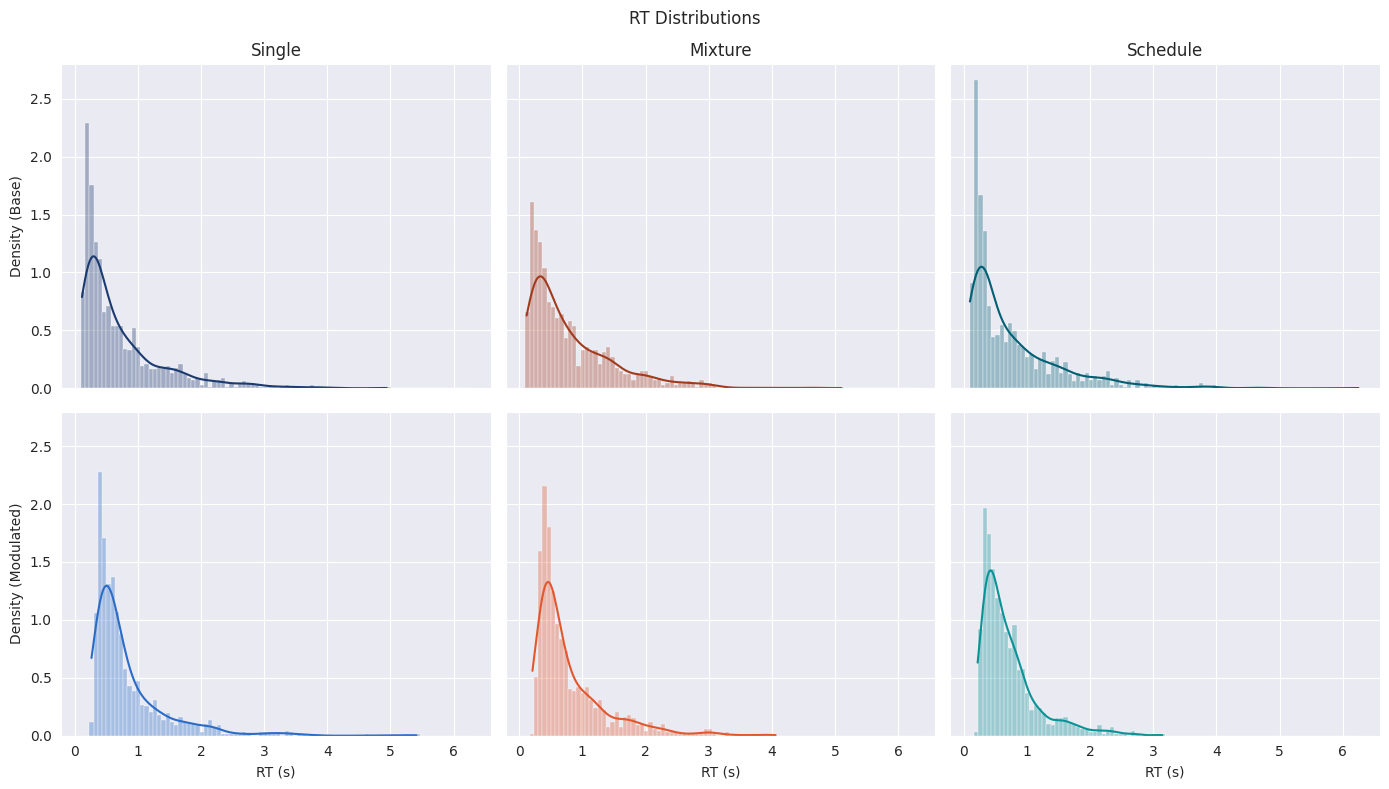

In [74]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)

for c, sc in enumerate(order_cols):
    for r, row_name in enumerate(row_labels):
        key = f"{sc}{'' if r == 0 else '_ctx'}"
        ax = axes[r, c]
        out = results[key]
        rt = out["rts"]
        m = ~np.isnan(rt)

        sns.histplot(rt[m], bins=bins, kde=True, stat="density", element="bars", fill=True,
                     alpha=0.35, ax=ax, color=palette[key])

        if r == 0:
            ax.set_title(sc.capitalize())
        if c == 0:
            ax.set_ylabel(f"Density ({row_name})")

axes[1,0].set_xlabel("RT (s)")
axes[1,1].set_xlabel("RT (s)")
axes[1,2].set_xlabel("RT (s)")
fig.suptitle("RT Distributions", y=0.98)
plt.tight_layout()

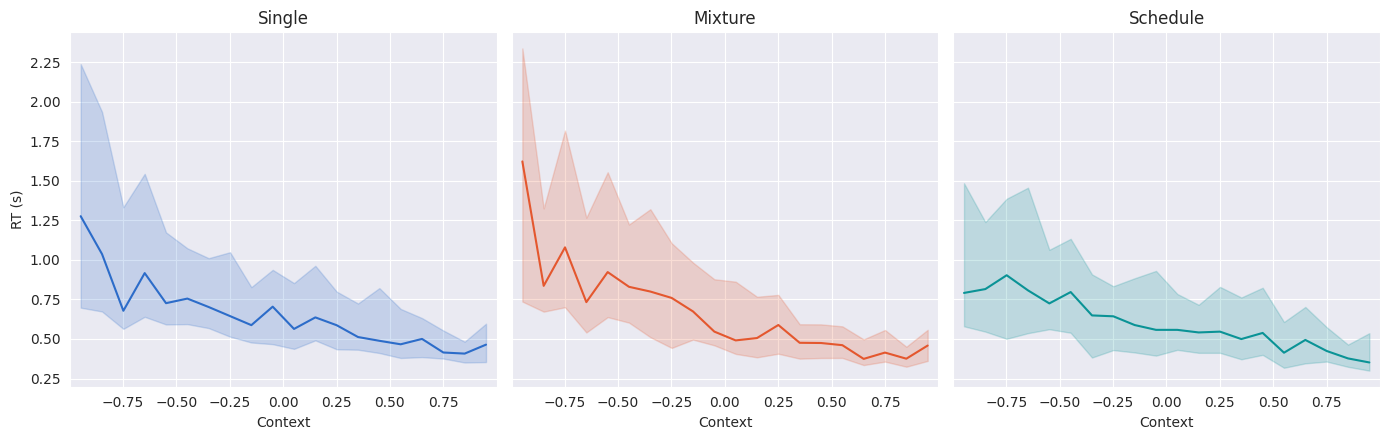

In [75]:
order_cols = ["single", "mixture", "schedule"]

# Common context range across all +ctx panels
ctx_vals = []
for sc in order_cols:
    key = f"{sc}_ctx"
    out = results.get(key, {})
    if out and "context" in out:
        m = _valid_mask(out["context"], out["rts"])
        if m.any():
            ctx_vals.append(out["context"][m])
ctx_rng = (np.min(np.concatenate(ctx_vals)), np.max(np.concatenate(ctx_vals))) if ctx_vals else None

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for c, sc in enumerate(order_cols):
    key = f"{sc}_ctx"
    ax = axes[c]
    out = results.get(key, {})
    if out and "context" in out:
        x, y = out["context"], out["rts"]
        xc, ym, lo, hi = binned_stats(x, y, nbins=20, rng=ctx_rng)
        if xc.size > 0:
            col = palette[key]
            ax.plot(xc, ym, color=col)
            ax.fill_between(xc, lo, hi, alpha=0.2, color=col)
        ax.set_xlim(*ctx_rng) if ctx_rng else None
    else:
        ax.text(0.5, 0.5, "no context", ha="center", va="center", transform=ax.transAxes, color="#666")
    ax.set_title(sc.capitalize())
    ax.set_xlabel("Context")
axes[0].set_ylabel("RT (s)")
plt.tight_layout()

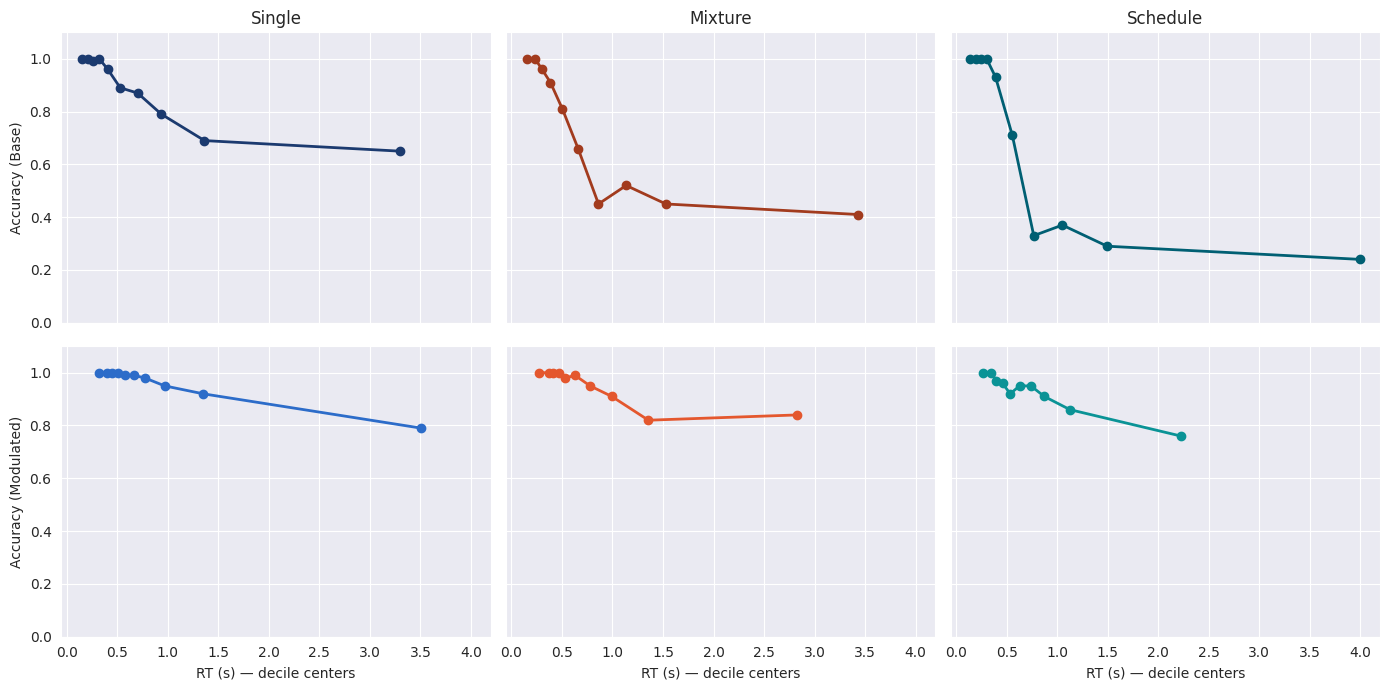

In [80]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)

for c, sc in enumerate(order_cols):
    for r, row_name in enumerate(row_labels):
        key = f"{sc}{'' if r == 0 else '_ctx'}"
        ax = axes[r, c]
        out = results[key]
        x, acc = compute_caf(out["rts"], out["choices"], n_bins=10)
        if x.size > 0:
            ax.plot(x, acc, marker="o", linewidth=2, color=palette[key])
        ax.set_ylim(0, 1.1)
        if r == 0:
            ax.set_title(sc.capitalize())
        if c == 0:
            ax.set_ylabel(f"Accuracy ({row_name})")

axes[1,0].set_xlabel("RT (s) — decile centers")
axes[1,1].set_xlabel("RT (s) — decile centers")
axes[1,2].set_xlabel("RT (s) — decile centers")
plt.tight_layout()

### Optional testing of `StandardDDM` and `CollapsingBoundDDM`

In [2]:
model = StandardDDM(dt=0.001, max_steps=10000)
params = {
    "v": 0.5, "a": 1.0, "z": 0.5, "tau": 0.2,
    "s_v": 0.1, "sigma": 1.0, "angle": 0.0, "s_z": 0.01, "s_tau": 0.01
}
output = model.simulate(params, num_samples=1000)
summary = model.summarize(output, tau=params["tau"])
print(summary)

{'invalid_rate': 0.0, 'rt_quantiles': array([0.29237604, 0.39485353, 0.5586146 , 0.904699  , 1.7153584 ],
      dtype=float32), 'rt_quantiles_by_choice': array([[0.657839  , 0.9146928 , 1.3505824 , 1.6934577 , 2.4648392 ],
       [0.28736928, 0.37797692, 0.51232773, 0.79669505, 1.4935193 ]],
      dtype=float32), 'dt_quantiles': array([0.09237605, 0.19485354, 0.35861465, 0.70469904, 1.5153583 ],
      dtype=float32), 'dt_quantiles_by_choice': array([[0.457839  , 0.71469283, 1.1505823 , 1.4934577 , 2.2648392 ],
       [0.08736928, 0.17797692, 0.31232774, 0.59669507, 1.2935193 ]],
      dtype=float32)}


In [3]:
# Example for CollapsingBoundDDM
model = CollapsingBoundDDM(dt=0.001, max_steps=10000)
params["angle"] = 0.1  # Non-zero for collapsing bounds
output = model.simulate(params, num_samples=1000)
summary = model.summarize(output, tau=params["tau"])
print(summary)

{'invalid_rate': 0.0, 'rt_quantiles': array([0.44570202, 0.6401622 , 0.89162195, 1.1846149 , 1.7200556 ],
      dtype=float32), 'rt_quantiles_by_choice': array([[0.4801869 , 0.64178234, 0.9334053 , 1.2457124 , 1.7594641 ],
       [0.43496436, 0.640117  , 0.86973757, 1.1585834 , 1.7105213 ]],
      dtype=float32), 'dt_quantiles': array([0.245702  , 0.44016224, 0.69162196, 0.9846149 , 1.5200555 ],
      dtype=float32), 'dt_quantiles_by_choice': array([[0.2801869 , 0.44178236, 0.73340535, 1.0457124 , 1.5594641 ],
       [0.23496436, 0.44011703, 0.6697376 , 0.9585835 , 1.5105213 ]],
      dtype=float32)}
